### C3M10: Data Cleaning Pt. 2

## CASE STUDY for today

Several years ago, on the first day of class, I asked students to fill out a survey.  

Here are the questions I asked:

* What is the probability you'll actually take this class  (should be a number between zero and one, inclusive)?
* What is your student status? (Undergradute, Graduate, Something Else)
* If you're a student, what year are you? (1 = freshman OR first year grad, etc.)
* In which division is your major (or likely major)? (Social Sciences, Humanities, Life Sciences, etc.)
* With which gender identiy to you most identify? (Female, Male, Gender non-conforming, Trans-gender, Choose not to answer)
* What is your height in cm?
* What is your handedness (Right handed, Left handed, Ambidextrous)
* How much (including tip) did you spend on your last haircut?
* How many minutes per week do you estimate that you exercise?
* How many minutes per day do you estimate you spend on coursework (not including time in class)?
* How many minutes per day do you estimate you surf the web or social media?   Don't include watching shows, do include watching mindless YouTube videos, time on TikTok or Instagram or Facebook or .....  Don't include anything related to academic activities.
* How many minutes per day do you estimate you watch shows?   Include Netflix, Hulu, actual TV, etc.
* On a scale of 1 to 7, how do you rate your SOCIAL political views? (1 = Extremely Conservative, 7 = Extremely Liberal, 4 = Moderate)
* On a scale of 1 to 7, how do you rate your ECONOMIC political views? (1 = Extremely Conservative, 7 = Extremely Liberal, 4 = Moderate)
* If you could be any animal, what would you be?
* How many close friends do you feel you have?
* Record your estimated pulse over 60 seconds


In [3]:
#This is to set global options so we can actually see all columns of a dataset when we ask for them
options(repr.matrix.max.cols = 150, repr.matrix.max.rows = 200)
library(car)
library(ggplot2)
library(dplyr)


Loading required package: carData




Attaching package: ‘dplyr’




The following object is masked from ‘package:car’:

    recode




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
#Get the survey data
survey <- read.csv("https://raw.githubusercontent.com/jreuning/sds230_data/refs/heads/main/class.survey.csv", header = TRUE, as.is = F)

#Get the dimension of the survey
dim(survey)

#What are the variables on the dataset?
names(survey)

#What data types were created?
str(survey)

[1] 239  17

[1] "ClassProb"  "Status"     "Year"       "Division"   "Gender"    
 [6] "HtCm"       "Hand"       "Haircut"    "Exercise"   "Coursework"
[11] "Web"        "TV"         "Social"     "Econ"       "Animal"    
[16] "Friends"    "Pulse"

'data.frame':	239 obs. of  17 variables:
 $ ClassProb : num  1 0.65 1 0.9 1 1 1 1 1 1 ...
 $ Status    : Factor w/ 2 levels "Graduate","Undergraduate": 2 2 2 2 2 2 2 1 2 2 ...
 $ Year      : Factor w/ 5 levels "1 = freshman or first year grad",..: 2 4 2 3 2 2 2 1 2 2 ...
 $ Division  : Factor w/ 6 levels "Humanities","Life Sciences",..: 4 2 2 1 6 6 6 6 6 4 ...
 $ Gender    : Factor w/ 5 levels "Choose not to answer",..: 4 4 2 5 2 4 2 2 2 2 ...
 $ HtCm      : num  191 190 162 173 160 ...
 $ Hand      : Factor w/ 3 levels "Ambidextrous",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ Haircut   : num  9 42 5 40 0 31 100 40 20 30 ...
 $ Exercise  : num  700 300 65 80 30 120 90 90 60 40 ...
 $ Coursework: Factor w/ 35 levels "1,260","1,380",..: 5 19 5 9 9 9 9 9 7 9 ...
 $ Web       : Factor w/ 35 levels "1","1,260","1.5",..: 25 23 8 24 31 8 13 17 31 31 ...
 $ TV        : int  0 15 20 60 10 45 0 0 15 20 ...
 $ Social    : Factor w/ 8 levels "1 = Extremely Conservative",..: 4 5 5 6 6 6 6 6 6 4 ...
 $ Econ    

How many complete survey responses do we have? `complete.cases()` creates a **LOGICAL** vector that tells us which cases are complete. 

In [3]:
complete.cases(survey)

#This counts TRUE as 1 and FALSE as 0.
sum(complete.cases(survey))

[1]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [13]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE
 [25]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [37]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [49]  TRUE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [61]  TRUE FALSE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [73]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE
 [85]  TRUE FALSE FALSE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE
 [97]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[109]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[121]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[133]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[145]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE
[157]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[169]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[181]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[193]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE  TRUE
[205]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[217]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[229]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE

[1] 229

To make a dataframe that **ONLY** has the complete cases we can do either of the following:

In [4]:
survey_com <- survey[complete.cases(survey), ]   #only keep rows where complete.cases = TRUE
dim(survey_com)
survey_com <- na.omit(survey)  #omit rows where there are any NAs i.e. any missing values

[1] 229  17

We could create an object that ONLY has rows with missing data to see what tends to be missing.


In [5]:
# ! is the 'not' operator.
survey_miss <- survey[!complete.cases(survey), ]
survey_miss

,ClassProb,Status,Year,Division,Gender,HtCm,Hand,Haircut,Exercise,Coursework,Web,TV,Social,Econ,Animal,Friends,Pulse
,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<int>
24,0.70,Undergraduate,1 = freshman or first year grad,Social Sciences,Male,182.88,Right handed,NA,NA,120,30,0,5,3,shark,4,NA
52,0.95,Undergraduate,1 = freshman or first year grad,"Physical Sciences, Engineering, Math",Female,162.50,Right handed,NA,0,160,120,100,7 = Extremely Liberal,5,Panda,5,90
62,99.00,Graduate,2 = sophomore or 2nd year grad,Professional School,Male,17.90,Right handed,7,90,90,100,200,2,5,,NA,NA
84,0.90,Undergraduate,2 = sophomore or 2nd year grad,"Physical Sciences, Engineering, Math",Female,165.00,Right handed,50,0,90,130,100,3,2,eagle,5,NA
86,1.00,Undergraduate,1 = freshman or first year grad,"Physical Sciences, Engineering, Math",Male,170.00,Right handed,20,445,45,120,30,6,5,"Cat, free food and housing for life while I do nothing",NA,58
87,1.00,Graduate,1 = freshman or first year grad,Professional School,Female,162.50,Right handed,75,200,360,30,NA,4 = Moderate,4 = Moderate,sphinx,4,58
92,0.70,Undergraduate,2 = sophomore or 2nd year grad,Humanities,Female,167.50,Right handed,NA,30,180,30,0,5,4 = Moderate,otter,6,NA
155,1.00,Undergraduate,2 = sophomore or 2nd year grad,Social Sciences,Female,152.40,Right handed,NA,120,180,180,0,7 = Extremely Liberal,7 = Extremely Liberal,a squid,3,72
156,1.00,Graduate,1 = freshman or first year grad,Professional School,Female,173.00,Right handed,NA,0,45,500,0,6,6,cat,1,80


A few things to note:
*   Very little missing data. Five missing pulses, several missing haircuts, a few random other variables
*   The row labels on survey_miss are the row numbers according the numbering in the COMPLETE data set.

### Investigate Variables

#### Gender

Let's start by looking at the distribution of gender responses.

In [6]:
table(survey$Gender)
levels(survey$Gender)


 Choose not to answer                Female Gender non-conforming 
                    1                   125                     4 
                 Male          Trans-gender 
                  108                     1 

[1] "Choose not to answer"  "Female"                "Gender non-conforming"
[4] "Male"                  "Trans-gender"

Since have insufficient data to say anything about levels that aren't 'Male' or 'Female' separately, I create a category that is simply 'Other or NS'

In [7]:
survey$Gender[survey$Gender %in% levels(survey$Gender)[c(1, 3, 5)]] <- "Choose not to answer"
table(survey$Gender)
levels(survey$Gender)



 Choose not to answer                Female Gender non-conforming 
                    6                   125                     0 
                 Male          Trans-gender 
                  108                     0 

[1] "Choose not to answer"  "Female"                "Gender non-conforming"
[4] "Male"                  "Trans-gender"

We still have levels of `Gender` that we're not using, AND label is not what we want.
To fix this use the `droplevels()` function.

In [8]:
survey$Gender <- droplevels(survey$Gender)
table(survey$Gender)

#Fix label for first level
levels(survey$Gender)[1] <- "Other or NS"

table(survey$Gender)


Choose not to answer               Female                 Male 
                   6                  125                  108 


Other or NS      Female        Male 
          6         125         108 

#### Height

We start with an overall boxplot of Height.

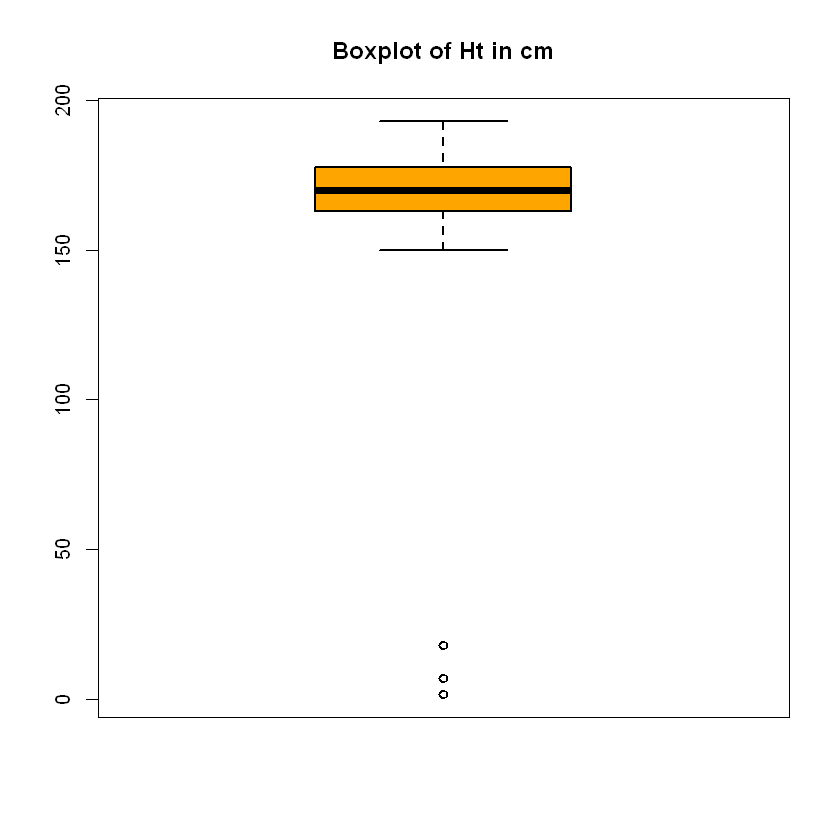

In [9]:
boxplot(survey$HtCm, main = "Boxplot of Ht in cm", col = 'orange', lwd = 2)

There are some surprising values here . . .   Let's look at data.

In [10]:
sort(survey$HtCm)

#Same thing to nearest 10th foot
round(sort(survey$HtCm)/2.5/12, 1)

[1]   1.60   1.76   7.00  17.90 150.00 150.00 152.40 152.50 152.50 153.00
 [11] 154.00 155.00 155.00 155.00 155.00 155.00 155.00 155.00 155.00 156.00
 [21] 157.00 157.00 157.00 157.00 157.48 157.50 157.50 157.50 157.50 157.50
 [31] 157.50 157.50 157.50 157.50 157.50 157.50 158.00 158.00 160.00 160.00
 [41] 160.00 160.00 160.00 160.00 160.00 160.00 160.00 160.00 160.00 160.00
 [51] 160.02 160.02 162.00 162.50 162.50 162.50 162.50 162.56 162.56 163.00
 [61] 163.00 163.00 163.00 163.00 163.50 164.00 165.00 165.00 165.00 165.00
 [71] 165.00 165.00 165.00 165.00 165.00 165.00 165.00 165.00 165.00 165.00
 [81] 165.10 166.00 166.00 166.00 166.00 167.00 167.00 167.00 167.00 167.00
 [91] 167.00 167.50 167.50 167.50 167.50 167.50 167.50 167.50 167.50 167.50
[101] 167.50 167.50 168.00 168.00 168.00 168.50 169.00 170.00 170.00 170.00
[111] 170.00 170.00 170.00 170.00 170.00 170.00 170.00 170.00 170.00 170.00
[121] 170.00 170.00 170.00 170.00 170.00 170.00 170.18 170.18 170.50 171.25
[131] 172.00 172.00 172.00 172.00 172.00 172.00 172.00 172.50 172.50 172.50
[141] 172.50 172.50 172.72 173.00 173.00 173.00 173.00 173.75 174.00 174.00
[151] 174.00 174.00 175.00 175.00 175.00 175.00 175.00 175.00 175.00 175.00
[161] 175.00 175.00 175.00 175.00 175.00 175.00 175.00 175.00 175.00 175.00
[171] 175.26 175.26 175.26 175.30 176.00 176.50 177.50 177.50 177.50 177.50
[181] 177.80 178.00 178.00 178.00 178.00 178.50 178.50 179.00 180.00 180.00
[191] 180.00 180.00 180.00 180.00 180.00 180.00 180.00 180.00 180.00 180.00
[201] 180.00 180.00 180.00 180.30 180.34 180.34 182.00 182.00 182.00 182.80
[211] 182.88 182.88 182.88 183.00 183.00 183.00 183.00 184.00 184.00 185.00
[221] 185.00 185.00 186.00 186.00 186.00 186.00 187.00 187.50 188.00 189.00
[231] 190.00 190.00 190.00 190.00 191.00 192.00 193.00 193.00 193.00

[1] 0.1 0.1 0.2 0.6 5.0 5.0 5.1 5.1 5.1 5.1 5.1 5.2 5.2 5.2 5.2 5.2 5.2 5.2
 [19] 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2 5.2
 [37] 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.3 5.4 5.4
 [55] 5.4 5.4 5.4 5.4 5.4 5.4 5.4 5.4 5.4 5.4 5.4 5.5 5.5 5.5 5.5 5.5 5.5 5.5
 [73] 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.6 5.6 5.6 5.6 5.6
 [91] 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.6 5.7
[109] 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7
[127] 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.7 5.8 5.8 5.8 5.8 5.8 5.8 5.8
[145] 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8
[163] 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.8 5.9 5.9 5.9 5.9 5.9 5.9
[181] 5.9 5.9 5.9 5.9 5.9 6.0 6.0 6.0 6.0 6.0 6.0 6.0 6.0 6.0 6.0 6.0 6.0 6.0
[199] 6.0 6.0 6.0 6.0 6.0 6.0 6.0 6.0 6.1 6.1 6.1 6.1 6.1 6.1 6.1 6.1 6.1 6.1
[217] 6.1 6.1 6.1 6.2 6.2 6.2 6.2 6.2 6.2 6.2 6.2 6.2 6.3 6.3 6.3 6.3 6.3 6.3
[235] 6.4 6.4 6.4 6.4 6.4

Let's assume these are unknown errors (it's unlikely anyone is less than 1 foot tall).  Replace unusual values with NA (not available), i.e. Missing, i.e. **WE DON'T KNOW.**

In [11]:
#We didn't have any super tall people, but I have had this happen in the past . .
survey$HtCm[survey$HtCm < 100 | survey$HtCm > 300] <- NA
survey$HtCm

[1] 191.00 190.00 162.50 173.00 160.00 165.00 165.00 167.00 158.00 165.00
 [11] 172.00 175.00 174.00 165.10 157.50 182.00 175.00 172.00 163.00 160.00
 [21] 167.50 167.50 193.00 182.88 177.50 165.00 180.00 157.50 175.26 160.00
 [31] 180.00 175.26 165.00 180.00 185.00 168.50 155.00 160.00 153.00 188.00
 [41] 172.00 160.00 177.50 175.00 180.30 168.00 178.00 160.00 170.00 160.00
 [51] 157.48 162.50 178.00 170.00 160.00 178.50 186.00 155.00 173.75 170.00
 [61] 174.00     NA 160.00 170.00 172.00 170.50 157.00 163.50 180.00 172.00
 [71] 183.00 174.00 180.00     NA 175.00 192.00 154.00 165.00 162.50 163.00
 [81] 182.00 173.00 150.00 165.00 167.00 170.00 162.50 186.00 178.00 167.50
 [91] 162.00 167.50 175.30 172.50 182.88 184.00 170.00 166.00 167.50 160.00
[101] 157.50 169.00 160.02 165.00 180.00 180.00 177.50 157.50 160.02 180.34
[111] 182.88 155.00 180.00 152.50 157.50 158.00 157.50 170.18 175.26 162.56
[121] 185.00 168.00 175.00 166.00 175.00 183.00 170.00 183.00 168.00 175.00
[131] 180.00 175.00 175.00 175.00 162.56 186.00 180.00 172.72 165.00 187.50
[141] 187.00 157.50 167.50 170.00 170.00 175.00 182.00 193.00 163.00 175.00
[151] 167.50 157.50 189.00 183.00 152.40 173.00 190.00 175.00 167.50 173.00
[161] 170.00 190.00 180.00 155.00 180.34 155.00 175.00 152.50 157.00 175.00
[171] 170.00 175.00 175.00 170.00 172.50 180.00 166.00 172.50 179.00 182.80
[181] 172.50 177.80 166.00 156.00 170.18 165.00 170.00 163.00 172.50 178.50
[191] 164.00 157.00 180.00     NA 170.00 167.00 170.00 175.00 167.50 170.00
[201] 193.00 155.00 185.00 170.00 167.00 160.00 176.00 172.00 171.25 190.00
[211] 176.50 170.00 165.00 165.00 167.50 180.00 155.00 178.00 172.00 167.00
[221] 167.50 180.00 150.00     NA 165.00 157.50 186.00 157.50 177.50 155.00
[231] 184.00 174.00 157.00 157.50 165.00 170.00 167.00 160.00 163.00

Let's make an updated boxplot with unusual points removed.

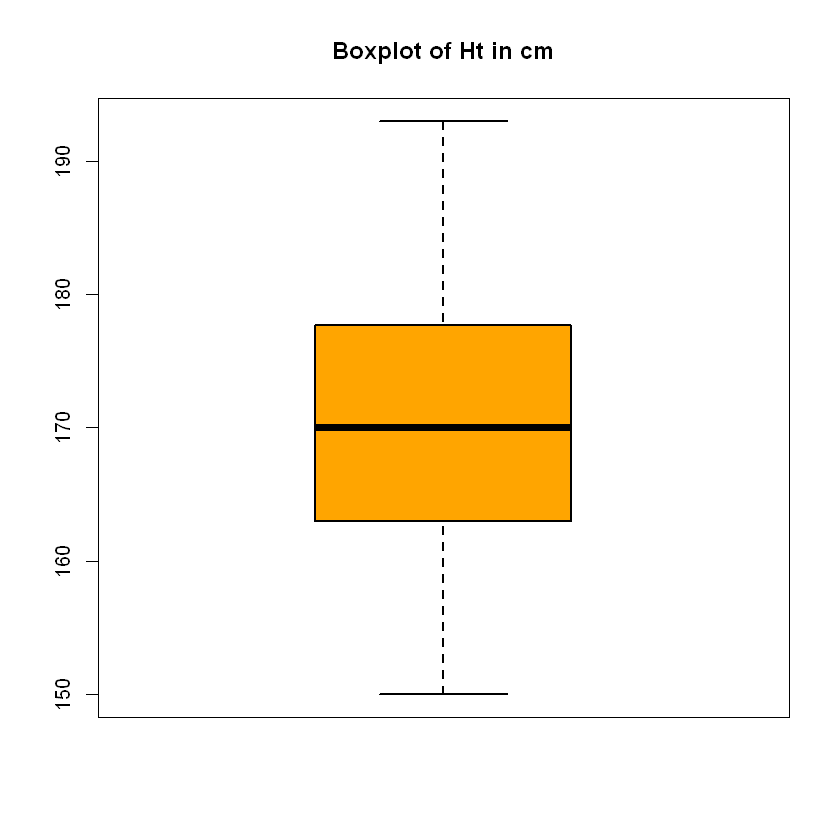

In [12]:
boxplot(survey$HtCm, main = "Boxplot of Ht in cm", col = 'orange', lwd = 2)

By the way, heights are usually approximately normally distributed.   Let's see if this is true by making a normal quantile plot.

[1]  23 148

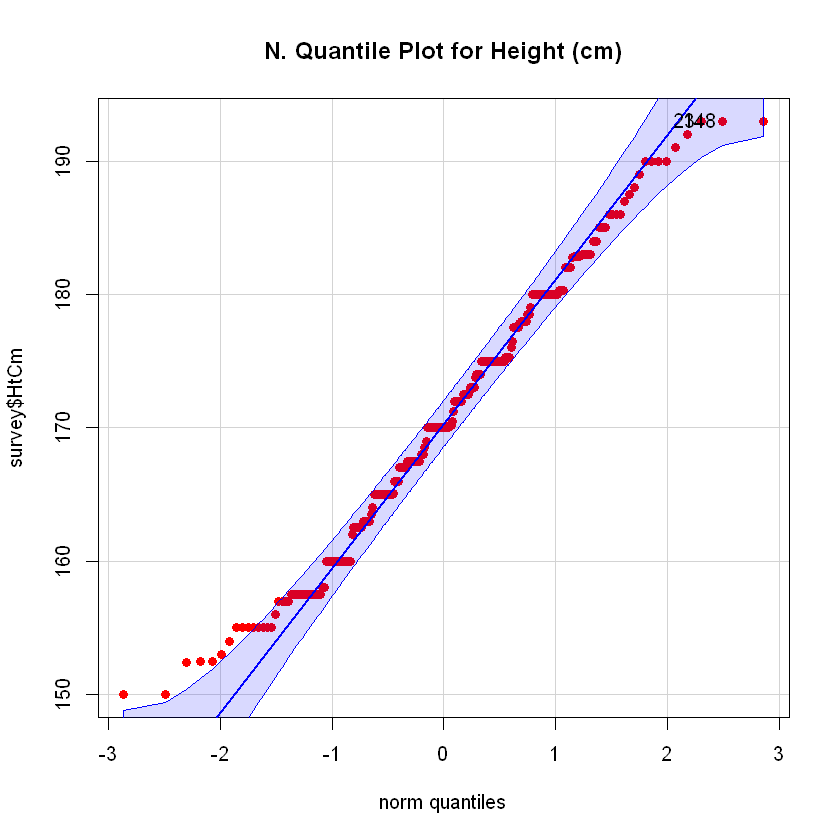

In [13]:
#Make a normal-quantile plot using qqp() in the car package
qqp(survey$HtCm, col = "red", col.lines = "blue", pch = 19, main = "N. Quantile Plot for Height (cm)")

*Next* - we make a boxplot of heights by identified gender.

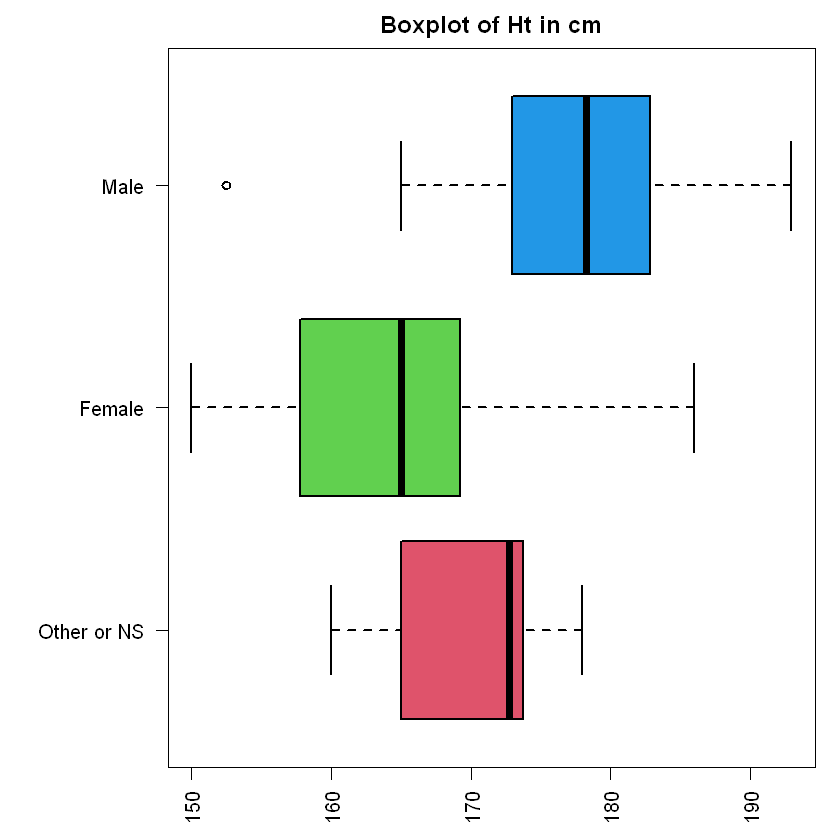

In [14]:
#The mar option is used to make more space on the left side of the graph
par(mar = c(3, 7, 2, 1))
boxplot(survey$HtCm ~ survey$Gender, main = "Boxplot of Ht in cm", col = c(2:4), 
        lwd = 2, 
        horizontal = TRUE, 
        las = 2, 
        ylab = "")

Unsurprisingly, in general people who identify as Male tend to be somewhat taller.  People identifying as Other or NS are right between Male and Female.

#### Pulse

Start with histogram of pulse overall.

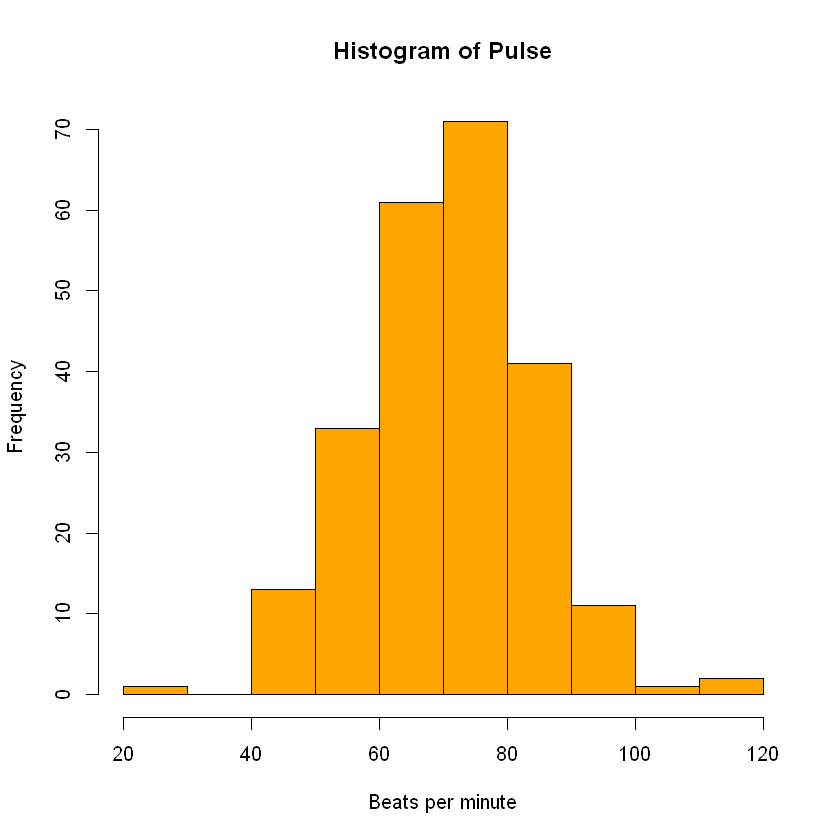

In [15]:
hist(survey$Pulse, 
     col = "orange", 
     breaks = 10, 
     main = "Histogram of Pulse",
     xlab = "Beats per minute")

Again, a couple of unusual values

[1]  20  42  42  45  45  45  45  48  48  49  50  50  50  50  51  52  52  53
 [19]  53  53  54  55  56  56  56  56  57  57  57  57  58  58  58  58  58  59
 [37]  59  60  60  60  60  60  60  60  60  60  60  61  62  62  62  62  62  62
 [55]  62  63  63  64  64  64  64  64  64  64  64  64  64  65  65  65  65  65
 [73]  65  65  66  66  66  66  67  67  68  68  68  68  68  68  68  68  68  69
 [91]  70  70  70  70  70  70  70  70  70  70  70  70  70  70  70  70  70  70
[109]  71  71  71  72  72  72  72  72  72  72  72  72  72  72  73  73  74  74
[127]  74  74  75  75  75  75  75  75  75  75  75  75  75  75  75  76  76  76
[145]  76  76  76  76  77  78  78  78  79  79  79  80  80  80  80  80  80  80
[163]  80  80  80  80  80  80  80  80  80  80  80  80  80  80  80  80  80  82
[181]  82  82  82  83  83  83  83  84  84  84  84  85  85  85  85  85  85  85
[199]  85  85  85  85  85  86  86  86  86  87  87  88  88  89  90  90  90  90
[217]  90  90  90  90  91  92  95  98  99 100 100 100 100 100 100 110 120 120

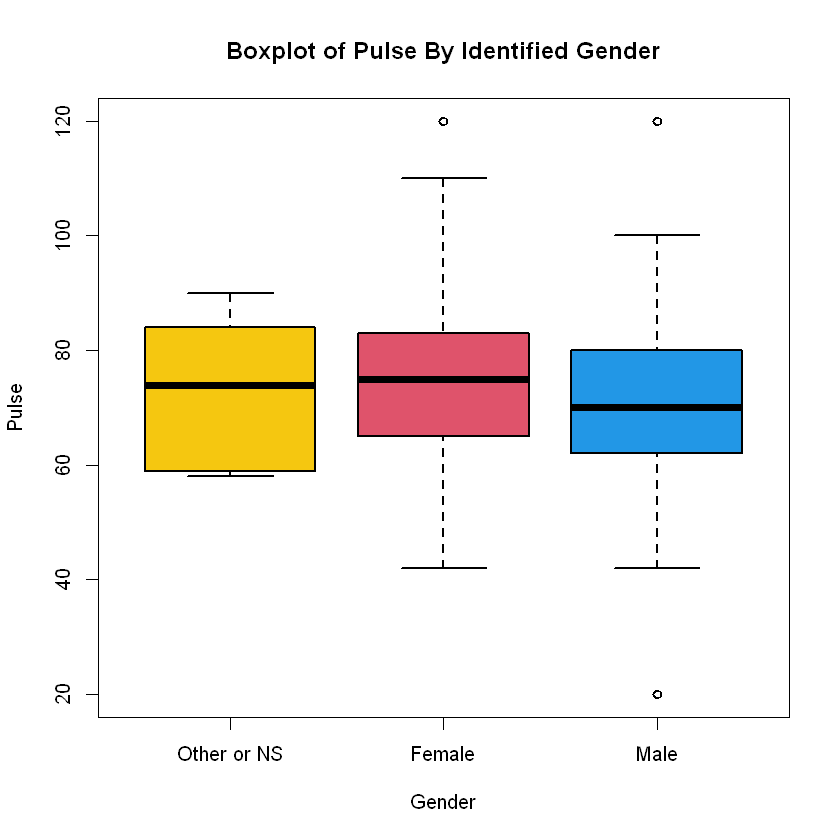

In [16]:
sort(survey$Pulse)

#I am curious who is barely alive
boxplot(Pulse ~ Gender, data = survey, main = "Boxplot of Pulse By Identified Gender", col = c(7,2,4), lwd = 2)

The American Heart Association says well trained athlete can have resting pulse of about 40.   We remove anything below 40.


In [17]:
#We remove anything below 40.
survey$Pulse[survey$Pulse < 40] <- NA

Incidentally, do pulse values seem normally distributed?

[1]   6 230

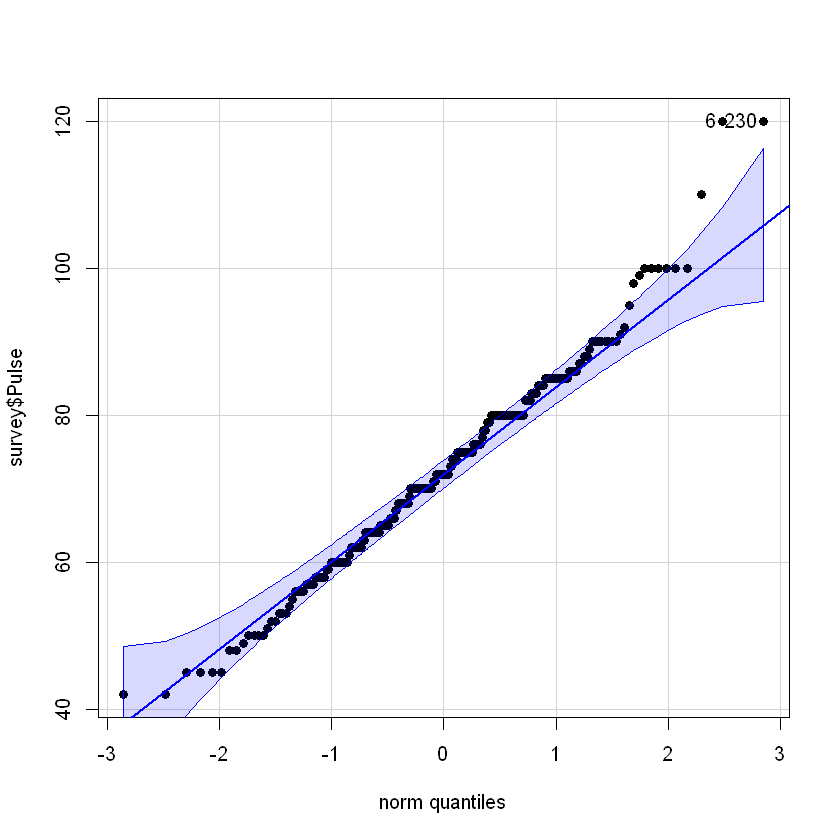

In [18]:
qqp(survey$Pulse, pch = 19)    
#overall, pretty close

#### Social and Economic Attitudes

First, let's look at the values of Social and Econ.

In [19]:
#I want to see the unique values
levels(survey$Social)
levels(survey$Econ)


[1] "1 = Extremely Conservative" "2"                         
[3] "3"                          "4 = Moderate"              
[5] "5"                          "6"                         
[7] "7 = Extremely Liberal"      "No answer text provided."

[1] ""                           "1 = Extremely Conservative"
[3] "2"                          "3"                         
[5] "4 = Moderate"               "5"                         
[7] "6"                          "7 = Extremely Liberal"

These are **NOT** numeric values - we need to pull off the numeric value which is always the first charachter in the string.

We use the  `substr()` function to get just the numeric values.

In [20]:
#Example of substr()

substr("Hi Mom", 2, 4)

[1] "i M"

In [21]:
substr(survey$Social, 1, 1)

survey$Social <- as.numeric(substr(survey$Social, 1, 1))
survey$Econ <- as.numeric(substr(survey$Econ, 1, 1))
#Make a table to see how often each pair of values occurs
table(survey$Econ, survey$Social)

[1] "4" "5" "5" "6" "6" "6" "6" "6" "6" "4" "4" "4" "4" "5" "4" "6" "5" "6"
 [19] "4" "6" "6" "5" "6" "5" "4" "7" "3" "3" "4" "6" "4" "4" "4" "6" "5" "6"
 [37] "6" "5" "5" "5" "4" "6" "5" "5" "4" "4" "6" "6" "4" "6" "N" "7" "5" "4"
 [55] "7" "5" "6" "4" "7" "5" "6" "2" "6" "6" "6" "2" "5" "4" "5" "6" "6" "6"
 [73] "4" "6" "5" "6" "7" "5" "5" "5" "3" "4" "N" "3" "5" "6" "4" "4" "3" "6"
 [91] "4" "5" "3" "7" "4" "4" "5" "6" "2" "6" "7" "4" "7" "5" "7" "6" "6" "6"
[109] "7" "3" "N" "6" "4" "7" "5" "5" "6" "6" "3" "5" "5" "6" "6" "5" "6" "5"
[127] "5" "5" "5" "6" "5" "6" "6" "1" "5" "7" "6" "4" "7" "6" "6" "5" "6" "6"
[145] "7" "7" "4" "5" "5" "5" "5" "5" "4" "5" "7" "6" "4" "5" "6" "6" "5" "5"
[163] "4" "6" "7" "6" "3" "5" "6" "5" "4" "3" "7" "4" "4" "5" "5" "4" "5" "4"
[181] "6" "6" "5" "6" "5" "5" "6" "5" "7" "5" "N" "5" "6" "N" "7" "6" "6" "5"
[199] "6" "7" "6" "5" "4" "5" "3" "6" "5" "4" "6" "2" "6" "4" "7" "3" "6" "5"
[217] "5" "5" "3" "6" "5" "4" "6" "6" "7" "6" "5" "6" "3" "6" "7" "6" "4" "6"
[235] "7" "6" "1" "4" "6"

Warning message:
"NAs introduced by coercion"


   
     1  2  3  4  5  6  7
  1  2  0  0  0  0  0  0
  2  0  0  4  0  1  1  0
  3  0  0  5  9 13  2  0
  4  0  1  3 29 20 21  0
  5  0  2  2  5 21 29  7
  6  0  1  0  1 10 22  5
  7  0  0  0  0  1  4 13

Let's make a scatterplot of these two variables.

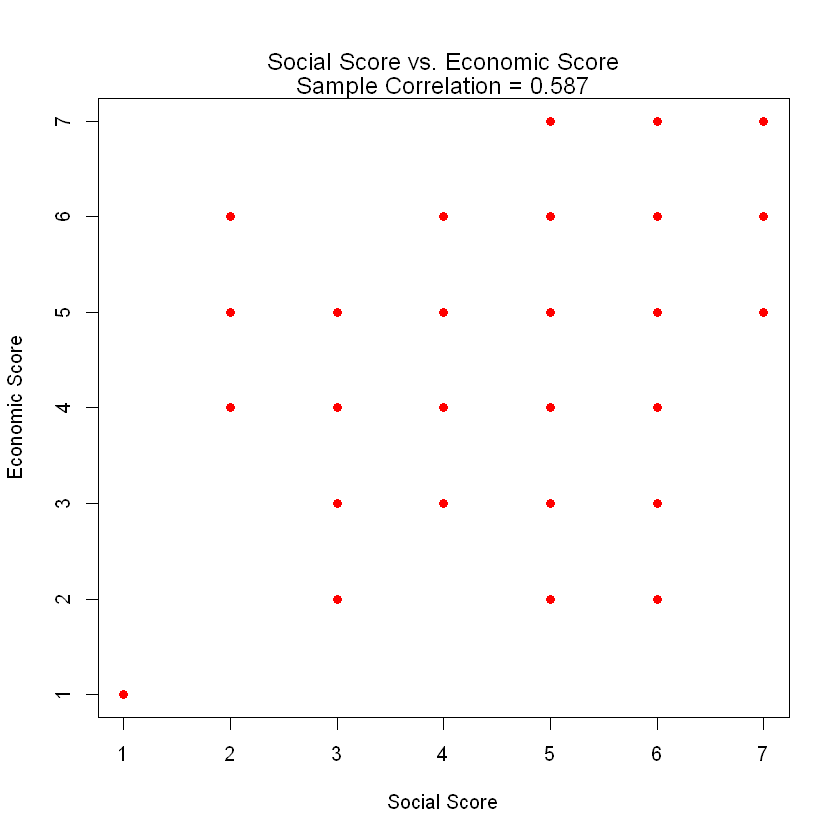

In [22]:
#Raw Scatterplot
plot(survey$Social, survey$Econ, pch = 19, col = "red", xlab = "Social Score",
     ylab = "Economic Score")
mtext(paste("Sample Correlation =", round(cor(survey$Social, survey$Econ, use = "complete.obs"), 3)), cex = 1.2, line = 0)
mtext("Social Score vs. Economic Score", cex = 1.2, line = 1)

This is hard to read (since we have many dots on top of each other).

##### Jittering

Jittering adds a small amount of random normally distributed noise to both the x and the y values.  This has the effect of 'smearing' data around a bit so that we can see observations more clearly.

You can jitter using the `jitter()` function.

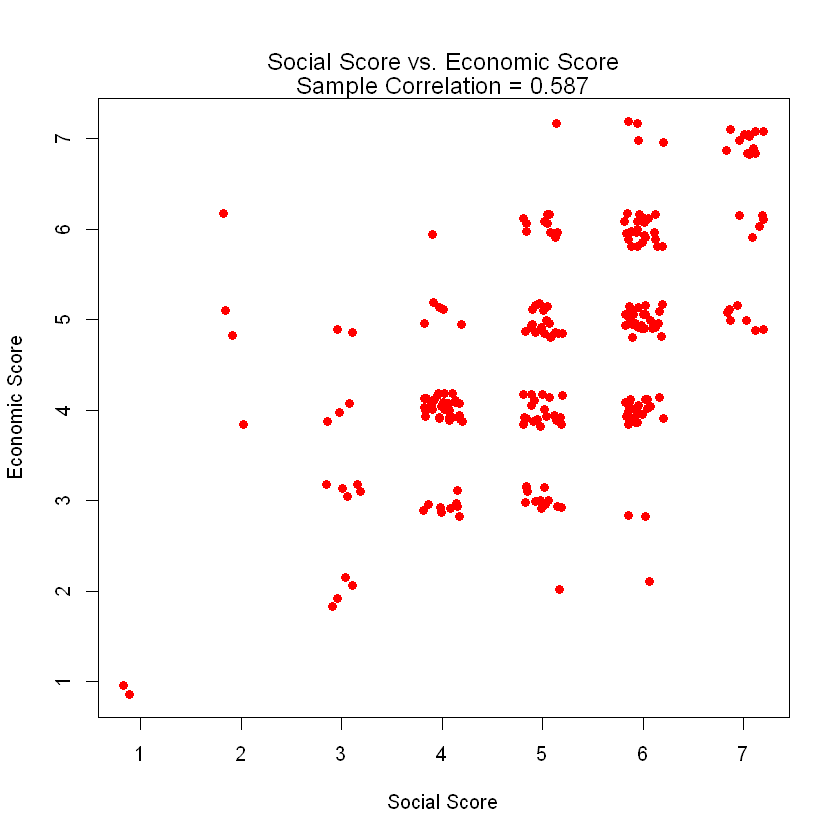

In [23]:
#Jittered
plot(jitter(survey$Social), jitter(survey$Econ), pch = 19, col = "red", xlab = "Social Score",
     ylab = "Economic Score")
mtext(paste("Sample Correlation =", round(cor(survey$Social, survey$Econ, use = "complete.obs"), 3)), cex = 1.2, line = 0)
mtext("Social Score vs. Economic Score", cex = 1.2, line = 1)

Another solution is to make the plot character area proportional to the number of individuals at each location.

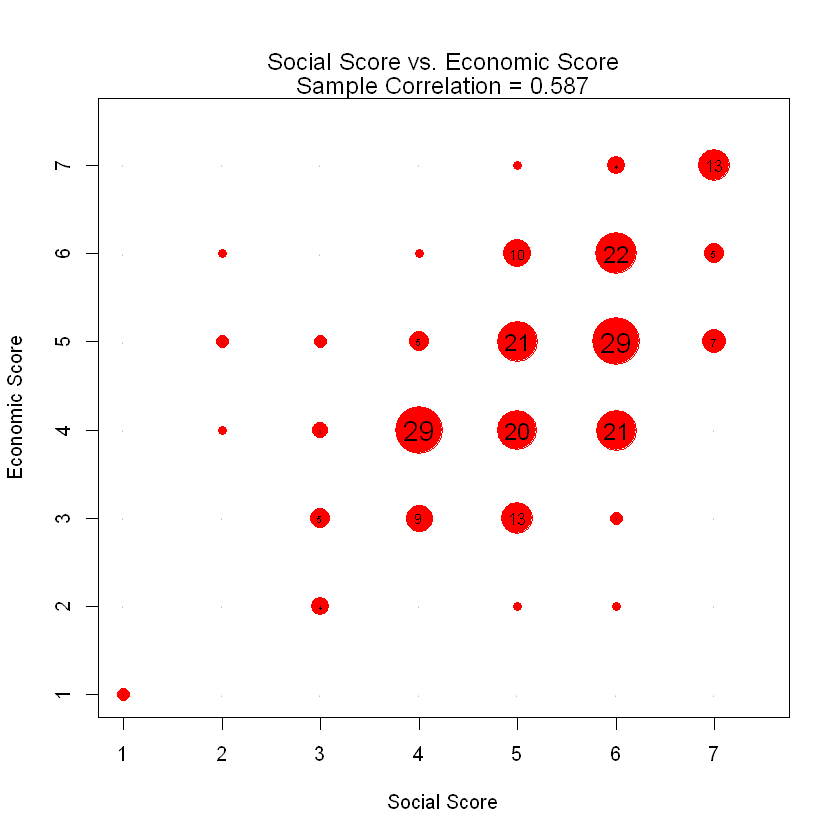

In [24]:

#Radii Proportional plot
#Get frequencies
freq <- c(table(survey$Social, survey$Econ))
#Get corresponding vectors, call them x1 and y1
x1 <- rep(c(1:7), 7)
y1 <- sort(rep(c(1:7),7))

#Make plot - area of character is proportional to frequency of occurence (i.e. square root of count)
plot(x1, y1, pch = 19, col = "red", xlab = "Social Score",
     ylab = "Economic Score", cex = sqrt(freq), ylim = c(1, 7.5), xlim = c(1, 7.5))

mtext(paste("Sample Correlation =", round(cor(survey$Social, survey$Econ, use = "complete.obs"), 3)), cex = 1.2, line = 0)
mtext("Social Score vs. Economic Score", cex = 1.2, line = 1)
text(x1, y1, freq, cex = log(freq/max(freq)*3 + 1)+.01, col = "black")


#### What Animal Would You Be?

In the survey, I restricted the responses students could enter.  This is good data collection practice - try to limit possibilities for respondents when possible.   

For example, if I simply asked "What is your height?" and let students determine how to respond, we might get

*  5'5
*  5' 5"
*  5 feet 5 inches
*  Five feet five inches
*  65 inches
*  65"
*  162.5 cm
*  etc.

Sometimes free responses are desired - and then these need cleaning!

Let's look at `Animal` - what animal would you like to be?

In [25]:
survey$Animal

[1] Lion                                                                                                                                                                                                            
  [2] Lion                                                                                                                                                                                                            
  [3] Owl                                                                                                                                                                                                             
  [4] Fox                                                                                                                                                                                                             
  [5] dolphin                                                                                                                                                                                                         
  [6] Chameleon                                                                                                                                                                                                       
  [7] octopus                                                                                                                                                                                                         
  [8] A bird!                                                                                                                                                                                                         
  [9] wolf                                                                                                                                                                                                            
 [10] elephant                                                                                                                                                                                                        
 [11] whale                                                                                                                                                                                                           
 [12] Eagle                                                                                                                                                                                                           
 [13] Cat                                                                                                                                                                                                             
 [14] dog                                                                                                                                                                                                             
 [15] a chameleon                                                                                                                                                                                                     
 [16] An orca                                                                                                                                                                                                         
 [17] Horse or owl                                                                                                                                                                                                    
 [18] Elephant                                                                                                                                                                                                        
 [19] wolf                                                                                                                          

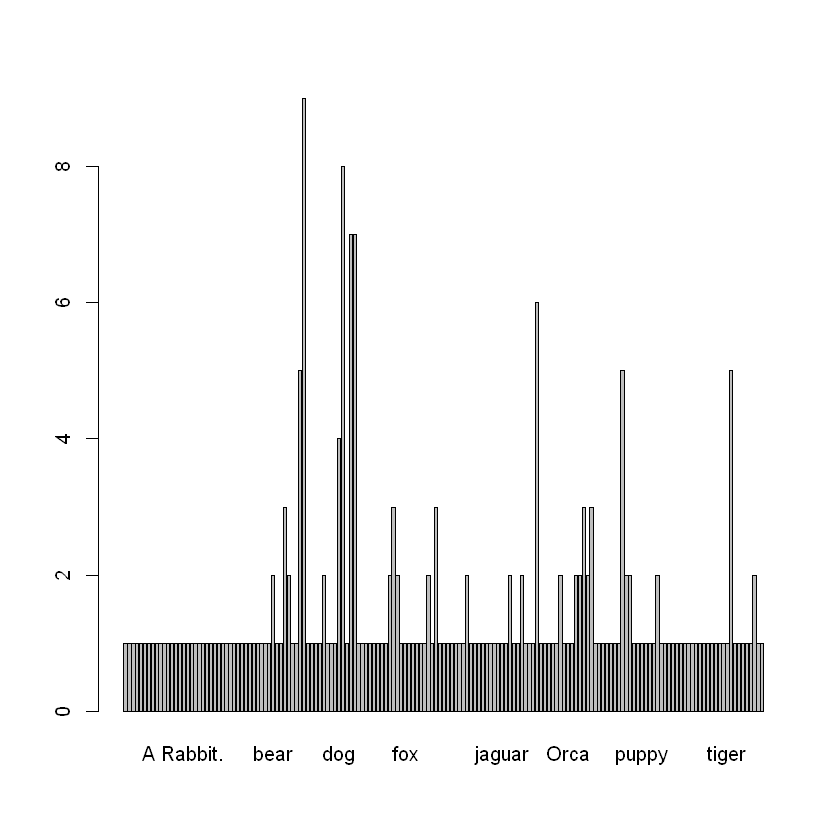

In [26]:
#Make a barplot
barplot(table(survey$Animal))  #not very helpful

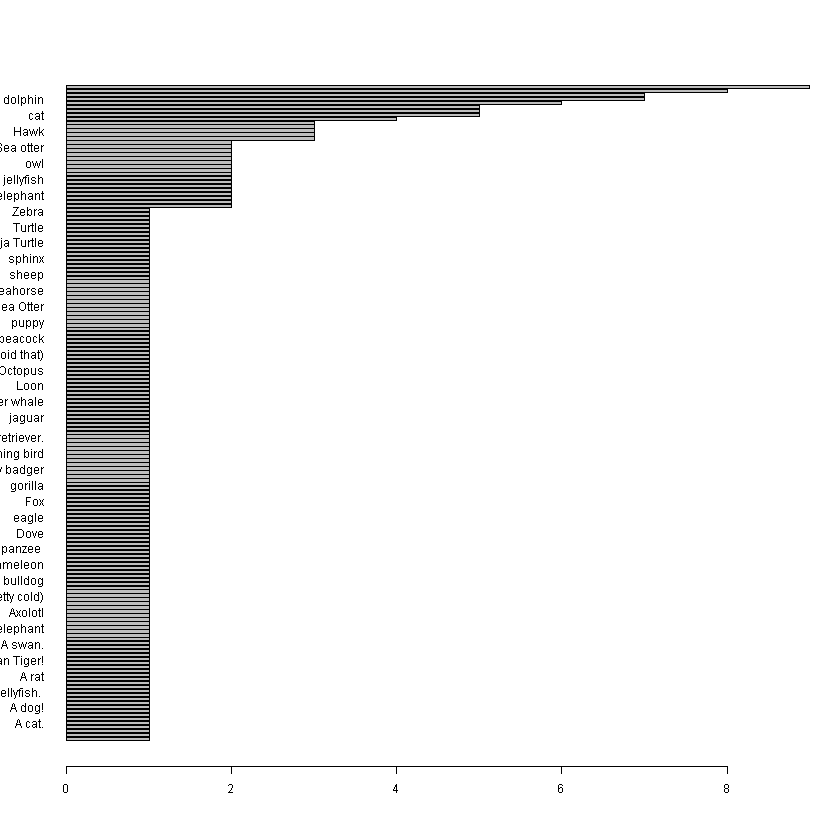

In [27]:
#Most common to least common - use the 'sort()' function
par(cex = 0.6)
barplot(sort(table(survey$Animal)), horiz = T, las = 1)  #still hard to read

We have many levels and lots of data cleaning is required.

What are the unique values?

In [28]:
#What unique levels were assigned?
levels(survey$Animal)   #165 unique levels so far
length(levels(survey$Animal))

[1] ""                                                                                                                                                                                                                
  [2] "A bird"                                                                                                                                                                                                          
  [3] "A bird because I want to fly. Maybe a hawk specifically. "                                                                                                                                                       
  [4] "A bird!"                                                                                                                                                                                                         
  [5] "A cat."                                                                                                                                                                                                          
  [6] "a chameleon "                                                                                                                                                                                                    
  [7] "A condor"                                                                                                                                                                                                        
  [8] "A dog"                                                                                                                                                                                                           
  [9] "A dog!"                                                                                                                                                                                                          
 [10] "A human being. If that doesn't count, a killer whale."                                                                                                                                                           
 [11] "A human, of course... but otherwise, maybe a cuttlefish."                                                                                                                                                        
 [12] "A hummingbird"                                                                                                                                                                                                   
 [13] "A jellyfish. "                                                                                                                                                                                                   
 [14] "A Penguin"                                                                                                                                                                                                       
 [15] "A penguin "                                                                                                                                                                                                      
 [16] "A Rabbit."                                                                                                                                                                                                       
 [17] "A rat"                                                                                                                                                                                                           
 [18] "A red panda"                                                                                                                                                                                                     
 [19] "A secretary bird.http://t2.gstatic.com/licensed-image?q=tbn:ANd9GcTOmjqMmWGSWBJDvXJfDbJ7o

[1] 165

Things to clean:
*    Replace any instance of "A (animal)" with just the name of the animal
*    Deal with upper/lower case
*    Comments and punctuation(!)
*    Some weird final symbols
*    Maybe reduce number of classes or remove modifiers (I would be a dog so I can be fed and sleep all day.)
*    ????
*    
Before we go further, we create a new object that will be our working object (so we have the original object in case we mess up)

In [29]:
animal <- survey$Animal
str(animal)

 Factor w/ 165 levels "","A bird","A bird because I want to fly. Maybe a hawk specifically. ",..: 107 108 119 74 59 50 113 4 163 69 ...


Use the `tolower()` function to make things lowercase.

In [30]:
#Make everything lowercase - use the tolower() function
animal <- tolower(animal)

#How many levels now?
levels(animal)
str(animal)

NULL

 chr [1:239] "lion" "lion " "owl" "fox" "dolphin" "chameleon" "octopus" ...


**BAH!**   What happened?  The problem is that `survey$Animal` is a **FACTOR**.   By using the `tolower()` function, we turned it into a string (text) variable.

This is actually fine - we'll use this as a text variable and convert back to factor later if we desire.

SO - how many unique values now?

In [31]:
unique(animal)     
length(unique(animal))  #down to 141

[1] "lion"                                                                                                                                                                                                            
  [2] "lion "                                                                                                                                                                                                           
  [3] "owl"                                                                                                                                                                                                             
  [4] "fox"                                                                                                                                                                                                             
  [5] "dolphin"                                                                                                                                                                                                         
  [6] "chameleon"                                                                                                                                                                                                       
  [7] "octopus"                                                                                                                                                                                                         
  [8] "a bird!"                                                                                                                                                                                                         
  [9] "wolf"                                                                                                                                                                                                            
 [10] "elephant"                                                                                                                                                                                                        
 [11] "whale"                                                                                                                                                                                                           
 [12] "eagle"                                                                                                                                                                                                           
 [13] "cat "                                                                                                                                                                                                            
 [14] "dog"                                                                                                                                                                                                             
 [15] "a chameleon "                                                                                                                                                                                                    
 [16] "an orca"                                                                                                                                                                                                         
 [17] "horse or owl"                                                                                                                                                                                                    
 [18] "jaguar"                                                                                                                                                                                                          
 [19] "a cat."                                                                                  

[1] 141

Let's sort alphabetically to make things easier to see.

In [32]:
sort(unique(animal))

[1] ""                                                                                                                                                                                                                
  [2] "a bird"                                                                                                                                                                                                          
  [3] "a bird because i want to fly. maybe a hawk specifically. "                                                                                                                                                       
  [4] "a bird!"                                                                                                                                                                                                         
  [5] "a cat."                                                                                                                                                                                                          
  [6] "a chameleon "                                                                                                                                                                                                    
  [7] "a condor"                                                                                                                                                                                                        
  [8] "a dog"                                                                                                                                                                                                           
  [9] "a dog!"                                                                                                                                                                                                          
 [10] "a human being. if that doesn't count, a killer whale."                                                                                                                                                           
 [11] "a human, of course... but otherwise, maybe a cuttlefish."                                                                                                                                                        
 [12] "a hummingbird"                                                                                                                                                                                                   
 [13] "a jellyfish. "                                                                                                                                                                                                   
 [14] "a penguin"                                                                                                                                                                                                       
 [15] "a penguin "                                                                                                                                                                                                      
 [16] "a rabbit."                                                                                                                                                                                                       
 [17] "a rat"                                                                                                                                                                                                           
 [18] "a red panda"                                                                                                                                                                                                     
 [19] "a secretary bird.http://t2.gstatic.com/licensed-image?q=tbn:and9gctomjqmmwgswbjdvxjfdbj7o

**NEXT**, remove any instance of "a (animal)" or "an (animal)" using the `gsub()` function.  `gsub()` looks for a text string and then replaces all instances with another text string inside of a character vector.

In [33]:
#example of gsub
gsub("man", "fungus", c("Superman", "Batman", "manatee"))

[1] "Superfungus" "Batfungus"   "fungusatee"

As you can see, this might have unexpected consequences.

In [34]:
gsub("a ", "", c("a dog", "a cat", "california condor"))

[1] "dog"             "cat"             "californicondor"

**PROBLEM** : we found all instances of `a ` (meaning the letter a followed by a space) and replaced them. This caused new problems : e.g.  `california condor` becames `californicondor`.

We want to replace ONLY when at the begining of the string.  Here's the solution : use `^` or `$`.

In [35]:
# Use a ^ at the start of the search string to indicate a search only at the beginning of a string
sort(unique(gsub("^a ", "", animal)))

#Use a $ to indicate search only at the end of a string
#this code would delete the letter r at the end of a string.
#sort(unique(gsub("r$", "", animal)))

[1] ""                                                                                                                                                                                                                
  [2] "alpaca"                                                                                                                                                                                                          
  [3] "an eagle"                                                                                                                                                                                                        
  [4] "an elephant"                                                                                                                                                                                                     
  [5] "an old english pocket beagle, specifically my dog charlie who has a very cushy life"                                                                                                                             
  [6] "an orca"                                                                                                                                                                                                         
  [7] "ant"                                                                                                                                                                                                             
  [8] "axolotl"                                                                                                                                                                                                         
  [9] "axolotyl"                                                                                                                                                                                                        
 [10] "bald eagle"                                                                                                                                                                                                      
 [11] "bald eagle in alaska - looks cool, patriotic, and i would love to see what alaska is like (though i would be pretty cold)"                                                                                       
 [12] "barn cat"                                                                                                                                                                                                        
 [13] "bear"                                                                                                                                                                                                            
 [14] "bird"                                                                                                                                                                                                            
 [15] "bird because i want to fly. maybe a hawk specifically. "                                                                                                                                                         
 [16] "bird!"                                                                                                                                                                                                           
 [17] "blue whale"                                                                                                                                                                                                      
 [18] "bulldog"                                                                                                                                                                                                         
 [19] "bunny"                                                                                   

This uses what is called a **Regular Expression*

*   A regular expression is a special text string for describing a search pattern
*   Programming languages all have regular expressions
*   R has many recognized regular expressions
*   In this case `^` means "search only at the beginning of the string"

Here are some links to learn more about regular expressions.

[A link to learn about regular expressions in general](https://en.wikipedia.org/wiki/Regular_expression)

[A link to commonly used regular expresions in R](https://github.com/rstudio/cheatsheets/blob/main/regex.pdf)

**SO** - let's actually make a few replacements


In [36]:
#Take out 'a ' at the beginning of words, write over the animal object
animal <- gsub("^a ", "", animal)

#Take out 'an ' at the beginning of words
animal <- gsub("^an ", "", animal)

#Fix instances of 'i would be a'
animal <- gsub("^i would be a ", "", animal)

#Fix instances of 'if i could be any animal i would be a '
animal <- gsub("^if i could be any animal i would be a ", "", animal)

#Now what are unique values?
sort(unique(animal)) 
length(sort(unique(animal)))  #down to 131

[1] ""                                                                                                                                                                                                                
  [2] "alpaca"                                                                                                                                                                                                          
  [3] "ant"                                                                                                                                                                                                             
  [4] "axolotl"                                                                                                                                                                                                         
  [5] "axolotyl"                                                                                                                                                                                                        
  [6] "bald eagle"                                                                                                                                                                                                      
  [7] "bald eagle in alaska - looks cool, patriotic, and i would love to see what alaska is like (though i would be pretty cold)"                                                                                       
  [8] "barn cat"                                                                                                                                                                                                        
  [9] "bear"                                                                                                                                                                                                            
 [10] "bird"                                                                                                                                                                                                            
 [11] "bird because i want to fly. maybe a hawk specifically. "                                                                                                                                                         
 [12] "bird!"                                                                                                                                                                                                           
 [13] "blue whale"                                                                                                                                                                                                      
 [14] "bulldog"                                                                                                                                                                                                         
 [15] "bunny"                                                                                                                                                                                                           
 [16] "cat"                                                                                                                                                                                                             
 [17] "cat "                                                                                                                                                                                                            
 [18] "cat, free food and housing for life while i do nothing "                                                                                                                                                         
 [19] "cat."                                                                                    

[1] 131

Next, we have some trailing spaces.   The '$' character denotes 'end of string' and we use an example of the escape character `\`

In [37]:
#The code below seems like it should work.
animal <- gsub(" $","", animal)
#sort(unique(animal))

#Another idea - specify that we are looking for a 'space' character.
#Single \ stands for 'escape character', i.e. we're not talking about text, and \s stands for 'space character'.
animal <- gsub("\\s$", "", animal)
#sort(unique(animal))

#Let's try the trimws() function
trimws(" this is a test ")
animal <- trimws(animal, which = "both")
sort(unique(animal))

[1] "this is a test"

[1] ""                                                                                                                                                                                                                
  [2] "alpaca"                                                                                                                                                                                                          
  [3] "ant"                                                                                                                                                                                                             
  [4] "axolotl"                                                                                                                                                                                                         
  [5] "axolotyl"                                                                                                                                                                                                        
  [6] "bald eagle"                                                                                                                                                                                                      
  [7] "bald eagle in alaska - looks cool, patriotic, and i would love to see what alaska is like (though i would be pretty cold)"                                                                                       
  [8] "barn cat"                                                                                                                                                                                                        
  [9] "bear"                                                                                                                                                                                                            
 [10] "bird"                                                                                                                                                                                                            
 [11] "bird because i want to fly. maybe a hawk specifically. "                                                                                                                                                         
 [12] "bird!"                                                                                                                                                                                                           
 [13] "blue whale"                                                                                                                                                                                                      
 [14] "bulldog"                                                                                                                                                                                                         
 [15] "bunny"                                                                                                                                                                                                           
 [16] "cat"                                                                                                                                                                                                             
 [17] "cat "                                                                                                                                                                                                            
 [18] "cat, free food and housing for life while i do nothing "                                                                                                                                                         
 [19] "cat."                                                                                    

We still have trailing spaces at the end of words which are clearly some other **unusual characters**.  

Different platforms/devices use different characters to indicate the end of a line.  These characters may be hidden and LOOK like spaces, but they are not space characters.

In addition, we have a web address, periods, etc.

We now use `[]` square brackets to ONLY allow particular hexidecimal characters. We also use the [^...] to indicate **NOT**.  This is another regular expression.


In [38]:
#The square brackets indicate that we're looking for particular characters.
#^ indicates we want anything that is NOT the identified characters.
#A quick example:
(tempvec <- c("This is test 9", "This is test nine", "this is test 9.", "9"))

grep("[0-9]", tempvec)
grep("[^0-9]", tempvec)
grep("[A-Z]", tempvec)
grep("[^A-Z]", tempvec)

[1] "This is test 9"    "This is test nine" "this is test 9."  
[4] "9"

[1] 1 3 4

[1] 1 2 3

[1] 1 2

[1] 1 2 3 4

In [41]:
#first we turn them all in '. This is so we can see where the special characters are hiding!
animal <- gsub("[^0-9A-Za-z/' ]", "/" , animal)

#Pause for quick copilot discussion - ask what line of code above does

#check out cat
sort(unique(animal))

#Now, remove all of the /

animal <- gsub("/", "" , animal)
sort(unique(animal))
length(sort(unique(animal)))    #now 120

[1] ""                                                                                                                                                                                                               
  [2] "alpaca"                                                                                                                                                                                                         
  [3] "ant"                                                                                                                                                                                                            
  [4] "axolotl"                                                                                                                                                                                                        
  [5] "axolotyl"                                                                                                                                                                                                       
  [6] "bald eagle"                                                                                                                                                                                                     
  [7] "bald eagle in alaska / looks cool/ patriotic/ and i would love to see what alaska is like /though i would be pretty cold/"                                                                                      
  [8] "barn cat"                                                                                                                                                                                                       
  [9] "bear"                                                                                                                                                                                                           
 [10] "bird"                                                                                                                                                                                                           
 [11] "bird because i want to fly/ maybe a hawk specifically//"                                                                                                                                                        
 [12] "bird/"                                                                                                                                                                                                          
 [13] "blue whale"                                                                                                                                                                                                     
 [14] "bulldog"                                                                                                                                                                                                        
 [15] "bunny"                                                                                                                                                                                                          
 [16] "cat"                                                                                                                                                                                                            
 [17] "cat/"                                                                                                                                                                                                           
 [18] "cat/ free food and housing for life while i do nothing/"                                                                                                                                                        
 [19] "chameleon"                                                                                                 

[1] ""                                                                                                                                                                                                         
  [2] "alpaca"                                                                                                                                                                                                   
  [3] "ant"                                                                                                                                                                                                      
  [4] "axolotl"                                                                                                                                                                                                  
  [5] "axolotyl"                                                                                                                                                                                                 
  [6] "bald eagle"                                                                                                                                                                                               
  [7] "bald eagle in alaska  looks cool patriotic and i would love to see what alaska is like though i would be pretty cold"                                                                                     
  [8] "barn cat"                                                                                                                                                                                                 
  [9] "bear"                                                                                                                                                                                                     
 [10] "bird"                                                                                                                                                                                                     
 [11] "bird because i want to fly maybe a hawk specifically"                                                                                                                                                     
 [12] "blue whale"                                                                                                                                                                                               
 [13] "bulldog"                                                                                                                                                                                                  
 [14] "bunny"                                                                                                                                                                                                    
 [15] "cat"                                                                                                                                                                                                      
 [16] "cat free food and housing for life while i do nothing"                                                                                                                                                    
 [17] "chameleon"                                                                                                                                                                                                
 [18] "cheetah"                                                                                                                                                                                                  
 [19] "chihuahua"                                                                                                                                                                                                
 [20] "chimp

[1] 120

Let's deal with a few mis-spellings.

In [42]:
#fix for humming bird
animal <- gsub("humming bird", "hummingbird", animal)

#fix spelling for axolotl
animal <- gsub("axolotyl", "axolotl", animal)

sort(unique(animal))
length(sort(unique(animal)))    #now 118

[1] ""                                                                                                                                                                                                         
  [2] "alpaca"                                                                                                                                                                                                   
  [3] "ant"                                                                                                                                                                                                      
  [4] "axolotl"                                                                                                                                                                                                  
  [5] "bald eagle"                                                                                                                                                                                               
  [6] "bald eagle in alaska  looks cool patriotic and i would love to see what alaska is like though i would be pretty cold"                                                                                     
  [7] "barn cat"                                                                                                                                                                                                 
  [8] "bear"                                                                                                                                                                                                     
  [9] "bird"                                                                                                                                                                                                     
 [10] "bird because i want to fly maybe a hawk specifically"                                                                                                                                                     
 [11] "blue whale"                                                                                                                                                                                               
 [12] "bulldog"                                                                                                                                                                                                  
 [13] "bunny"                                                                                                                                                                                                    
 [14] "cat"                                                                                                                                                                                                      
 [15] "cat free food and housing for life while i do nothing"                                                                                                                                                    
 [16] "chameleon"                                                                                                                                                                                                
 [17] "cheetah"                                                                                                                                                                                                  
 [18] "chihuahua"                                                                                                                                                                                                
 [19] "chimpanzee"                                                                                                                                                                                               
 [20] "clark

[1] 118

**NEXT** - deal with animals with modifiers (like 'dog in a rich suburban family or maybe a sloth')    Replace any text before or after animal name.

In [43]:
#We could do one animal at a time
dogtrial <- gsub(".*dog.*", "dog", animal)
sort(unique(dogtrial))  

[1] ""                                                                                                                                                                                                         
  [2] "alpaca"                                                                                                                                                                                                   
  [3] "ant"                                                                                                                                                                                                      
  [4] "axolotl"                                                                                                                                                                                                  
  [5] "bald eagle"                                                                                                                                                                                               
  [6] "bald eagle in alaska  looks cool patriotic and i would love to see what alaska is like though i would be pretty cold"                                                                                     
  [7] "barn cat"                                                                                                                                                                                                 
  [8] "bear"                                                                                                                                                                                                     
  [9] "bird"                                                                                                                                                                                                     
 [10] "bird because i want to fly maybe a hawk specifically"                                                                                                                                                     
 [11] "blue whale"                                                                                                                                                                                               
 [12] "bunny"                                                                                                                                                                                                    
 [13] "cat"                                                                                                                                                                                                      
 [14] "cat free food and housing for life while i do nothing"                                                                                                                                                    
 [15] "chameleon"                                                                                                                                                                                                
 [16] "cheetah"                                                                                                                                                                                                  
 [17] "chihuahua"                                                                                                                                                                                                
 [18] "chimpanzee"                                                                                                                                                                                               
 [19] "clarks nutcracker bird they have a really fascinating relationship with whitebark pine trees and it would be amazing to fly"                                                                              
 [20] "condo

The regular expresion period `.` stands for 'any character'.   The regular expression `*` stands for 'any number of times'.

Of course, there are other animals besides dog that have modifiers.   We could modify the code above for each animal.  Or  . . . we could make a vector of animals to fix  **AND** let's use our first loop!

The code below also is our next use of the `paste()`function.   `paste()` is useful for putting multiple character values together into a single string.  Note that `sep = ""` specifies the character to put between parts of paste (i.e. don't put anything between bits. By default, `paste()` puts a single space between each bit)

In [44]:
#An second example of the paste function.  Note it puts in a single space between each bit by default.
paste("Hi All,", round(3.14159, 2), "is my favorite", "number!")
paste0("Hi All,", round(3.14159, 2), "is my favorite", "number!")


[1] "Hi All, 3.14 is my favorite number!"

[1] "Hi All,3.14is my favoritenumber!"

In [45]:
#Create a temporary character vector of animal names that appear with modifiers.  This code requires judgement choices.
#ALSO - NOTE ORDER MATTERS!!!!    FIX PANDA BEFORE BEAR.
anvec <- c("panda", "wolf","dog","koala", "human", "bear","lion", "parrot", "penguin", "eagle", "monkey", "dolphin", 
           "narwhal", "cat", "golden retriever", "tortoise", "whale", "sloth", "owl", "turtle", "hawk", "secretary bird", 
           "jaguar", "clarks nutcracker", "tiger", "falcon", "squirrel")

#These next two lines are just for testing as I'll show in class
#i <- 3
#rm(i)

#Loop our way through each animal on the list and remove words before and after.
for (i in 1:length(anvec)){
   animal <- gsub(paste0(".*", anvec[i] ,".*"), anvec[i], animal)
}
sort(unique(animal))   #down to 80

[1] ""                     "alpaca"               "ant"                 
 [4] "axolotl"              "bear"                 "bird"                
 [7] "bunny"                "cat"                  "chameleon"           
[10] "cheetah"              "chihuahua"            "chimpanzee"          
[13] "clarks nutcracker"    "condor"               "dog"                 
[16] "dolphin"              "dove"                 "dragon"              
[19] "dragonfly"            "duck"                 "eagle"               
[22] "elephant"             "falcon"               "fox"                 
[25] "giant squid"          "golden pomeranian"    "golden retriever"    
[28] "goldendoodle"         "gorilla"              "hawk"                
[31] "hedgehog"             "highland cow"         "honey badger"        
[34] "human"                "hummingbird"          "jaguar"              
[37] "jdrs hes a beast"     "jellyfish"            "judy from zootopia"  
[40] "kangaroo"             "koala"                "lion"                
[43] "loon"                 "mantis shrimp"        "monkey"              
[46] "octopus"              "orca"                 "otter"               
[49] "owl"                  "panda"                "panther"             
[52] "parrot"               "peacock"              "penguin"             
[55] "pigeon"               "pikachu"              "puppy"               
[58] "puss in boots"        "quokka"               "rabbit"              
[61] "rat"                  "sea otter"            "seagull"             
[64] "seahorse"             "secretary bird"       "shark"               
[67] "sheep"                "sloth"                "sphinx"              
[70] "squid"                "squirrel"             "swan"                
[73] "tardigrade"           "tiger"                "tortoise"            
[76] "tulkun from avatar 2" "turtle"               "whale"               
[79] "wolf"                 "zebra"

Notice that I decided panda should win over bear.  If I had put bear first in the list, it would have turned 'panda bear' into 'bear'.

Let's make a table and see about frequency


In [46]:
table1 <- data.frame(sort(table(animal), decreasing = T))
table1
sort(unique(animal))  #still at 80

animal,Freq
<fct>,<int>
cat,22
dog,20
dolphin,15
panda,10
lion,9
eagle,8
penguin,7
tiger,7
bird,6


[1] ""                     "alpaca"               "ant"                 
 [4] "axolotl"              "bear"                 "bird"                
 [7] "bunny"                "cat"                  "chameleon"           
[10] "cheetah"              "chihuahua"            "chimpanzee"          
[13] "clarks nutcracker"    "condor"               "dog"                 
[16] "dolphin"              "dove"                 "dragon"              
[19] "dragonfly"            "duck"                 "eagle"               
[22] "elephant"             "falcon"               "fox"                 
[25] "giant squid"          "golden pomeranian"    "golden retriever"    
[28] "goldendoodle"         "gorilla"              "hawk"                
[31] "hedgehog"             "highland cow"         "honey badger"        
[34] "human"                "hummingbird"          "jaguar"              
[37] "jdrs hes a beast"     "jellyfish"            "judy from zootopia"  
[40] "kangaroo"             "koala"                "lion"                
[43] "loon"                 "mantis shrimp"        "monkey"              
[46] "octopus"              "orca"                 "otter"               
[49] "owl"                  "panda"                "panther"             
[52] "parrot"               "peacock"              "penguin"             
[55] "pigeon"               "pikachu"              "puppy"               
[58] "puss in boots"        "quokka"               "rabbit"              
[61] "rat"                  "sea otter"            "seagull"             
[64] "seahorse"             "secretary bird"       "shark"               
[67] "sheep"                "sloth"                "sphinx"              
[70] "squid"                "squirrel"             "swan"                
[73] "tardigrade"           "tiger"                "tortoise"            
[76] "tulkun from avatar 2" "turtle"               "whale"               
[79] "wolf"                 "zebra"


We're getting closer - but lots of singletons still.  I decided to do some grouping: these are just my preferences - you could make very different choices!

Make these changes.

In [47]:
#I make regular of the | operator which stands for 'or'.

#create a backup in case we change our minds
animal_backup <- animal
#animal <- animal_backup

#NOTE - some of these replacements are from other years - but they work just the same since they only make replacements if found

#dog
animal <- gsub("australian shepherd|golden retriever|handsome dan|puppy|labrador|goldendoodle|golden pomeranian|puppy|chihuahua", "dog", animal)

#Birds
animal <- gsub("goshawk|falcon|owl|eagle|hawk|condor", "raptor", animal)
animal <- gsub("crow|cardinal|hummingbird|parrot|peacock|dove|clarks nutcracker|duck|loon|pidgeon|pigeon|secretary bird|swan|seagull", "bird", animal)

#Bunny
animal <- gsub("bunny", "rabbit", animal)

#Large cats
animal <- gsub("black panther|cheetah|jaguar|lion|liger|tiger|leopard|lynx|panther", "large cat", animal)

#large sea mammals
animal <- gsub("whale|orca|dolphin|porpoise|narwhal", "whale or dolphin", animal)

#primates
animal <- gsub("gorilla|monkey|gibbon|bonobo|orangutan|chimpanzee", "primates", animal)

#humans
animal <- gsub("jdrs hes a beast", "human", animal)

#Other water creatures with fewer than 3 counts
animal <- gsub("axolotl|giant squid|shark|jelly fish|mantis shrimp|seahorse|tardigrade", "other water creature", animal)

#Imaginary creatures
animal <- gsub("tulkun from avatar 2|puss in boots|judy from zootopia|pikachu|dragon", "imaginary", animal)

#remove missing values
animal <- animal[animal != ""]

#Check where we are
table1 <- data.frame(sort(table(animal),decreasing=T))
table1    #Down to 40 categories
sort(unique(animal))

animal,Freq
<fct>,<int>
dog,25
raptor,25
bird,23
large cat,23
cat,22
whale or dolphin,22
panda,10
other water creature,8
penguin,7


[1] "alpaca"               "ant"                  "bear"                
 [4] "bird"                 "cat"                  "chameleon"           
 [7] "dog"                  "elephant"             "fox"                 
[10] "hedgehog"             "highland cow"         "honey badger"        
[13] "human"                "imaginary"            "imaginaryfly"        
[16] "jellyfish"            "kangaroo"             "koala"               
[19] "large cat"            "octopus"              "other water creature"
[22] "otter"                "panda"                "penguin"             
[25] "primates"             "quokka"               "rabbit"              
[28] "raptor"               "rat"                  "sea otter"           
[31] "sheep"                "sloth"                "sphinx"              
[34] "squid"                "squirrel"             "tortoise"            
[37] "turtle"               "whale or dolphin"     "wolf"                
[40] "zebra"

**LAST STEP** - everything from 'chameleon' down we'll call `misc`.

In [48]:
#chameleon is in row 21 of our temporary table
#rm(i)
for (i in 21:40){                      #start in row 21, finish in row 42
  animal <- gsub(paste0("^", as.character(table1[i, 1])), "misc. animal", animal)    
  #lookup table, find in animal, call misc.
}

#Check where we are
table2 <- data.frame(sort(table(animal), decreasing = T))
table2    #Down to 21 categories

animal,Freq
<fct>,<int>
misc. animal,27
dog,25
raptor,25
bird,23
large cat,23
cat,22
whale or dolphin,22
panda,10
other water creature,8


In [49]:
#Make table of results and store in finaltab
(finaltab <- table(animal))

animal
                bear                 bird                  cat 
                   4                   23                   22 
                 dog             elephant                human 
                  25                    6                    5 
           imaginary            jellyfish            large cat 
                   5                    4                   23 
        misc. animal              octopus other water creature 
                  27                    3                    8 
               panda              penguin             primates 
                  10                    7                    6 
              raptor            sea otter                sloth 
                  25                    3                    3 
              turtle     whale or dolphin                 wolf 
                   4                   22                    3 

**LAST thing** - We make a sorted barplot with added percentages on the labels

In [50]:
#Calculate percents, round to nearest percent
percents <- round(finaltab/sum(finaltab)*100, 1)
percents

animal
                bear                 bird                  cat 
                 1.7                  9.7                  9.2 
                 dog             elephant                human 
                10.5                  2.5                  2.1 
           imaginary            jellyfish            large cat 
                 2.1                  1.7                  9.7 
        misc. animal              octopus other water creature 
                11.3                  1.3                  3.4 
               panda              penguin             primates 
                 4.2                  2.9                  2.5 
              raptor            sea otter                sloth 
                10.5                  1.3                  1.3 
              turtle     whale or dolphin                 wolf 
                 1.7                  9.2                  1.3 

                bear (1.7%)                 bird (9.7%) 
                          4                          23 
                 cat (9.2%)                 dog (10.5%) 
                         22                          25 
            elephant (2.5%)                human (2.1%) 
                          6                           5 
           imaginary (2.1%)            jellyfish (1.7%) 
                          5                           4 
           large cat (9.7%)        misc. animal (11.3%) 
                         23                          27 
             octopus (1.3%) other water creature (3.4%) 
                          3                           8 
               panda (4.2%)              penguin (2.9%) 
                         10                           7 
            primates (2.5%)              raptor (10.5%) 
                          6                          25 
           sea otter (1.3%)                sloth (1.3%) 
                          3    

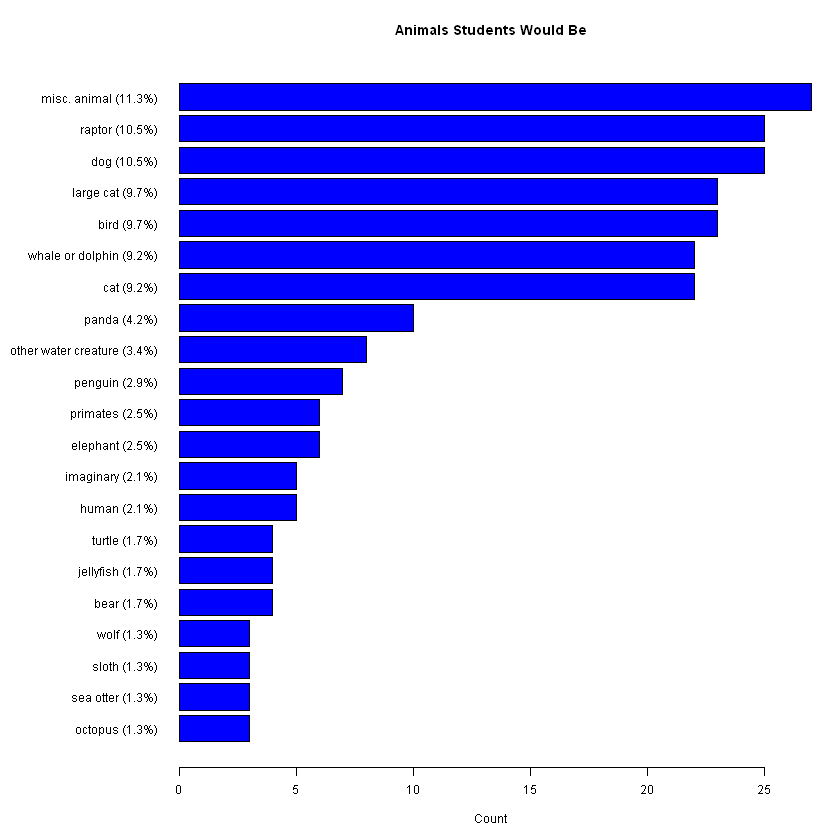

In [51]:
names(finaltab) <- paste0(names(finaltab)," (", percents, "%)")

#Check where we're at
finaltab

par(mar = c(5, 12, 4, 2), cex = 0.6)
#FINAL PLOT
barplot(sort(finaltab), horiz = T, las = 1, col = "blue", main = "Animals Students Would Be", xlab = "Count") 

The End!